# Week 4 — Constrained Optimisation I
## Lagrange Multipliers & Economic Applications

**Optimisation & Mathematical Methods for Economics**
The University of Edinburgh · School of Economics

---

Most economic decisions involve constraints: budgets, resource limits, time. This week introduces the **method of Lagrange multipliers** for equality-constrained optimisation.

## 1. The Lagrangian

**Problem:** Maximise (or minimise) $f(\mathbf{x})$ subject to $g(\mathbf{x}) = 0$.

**Lagrangian:** $\mathcal{L}(\mathbf{x}, \lambda) = f(\mathbf{x}) - \lambda \, g(\mathbf{x})$

**First-order conditions:**
$$\nabla_\mathbf{x} \mathcal{L} = \nabla f - \lambda \nabla g = \mathbf{0}$$
$$g(\mathbf{x}) = 0$$

The multiplier $\lambda$ measures the **shadow value** of the constraint: how much the optimum changes per unit relaxation of the constraint.

## 2. Utility Maximisation

A consumer maximises $u(x_1, x_2) = x_1^{\alpha} x_2^{1-\alpha}$ subject to $p_1 x_1 + p_2 x_2 = m$.

**Lagrangian:** $\mathcal{L} = x_1^\alpha x_2^{1-\alpha} - \lambda(p_1 x_1 + p_2 x_2 - m)$

**FOCs:**
- $\alpha x_1^{\alpha-1} x_2^{1-\alpha} = \lambda p_1$
- $(1-\alpha) x_1^\alpha x_2^{-\alpha} = \lambda p_2$

Dividing: $\frac{\alpha}{1-\alpha} \cdot \frac{x_2}{x_1} = \frac{p_1}{p_2}$

**Marshallian demands:** $x_1^* = \frac{\alpha m}{p_1}, \quad x_2^* = \frac{(1-\alpha)m}{p_2}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Cobb-Douglas utility maximisation
alpha = 0.4
p1, p2, m = 2, 3, 120

# Analytical solution
x1_star = alpha * m / p1
x2_star = (1 - alpha) * m / p2
u_star = x1_star**alpha * x2_star**(1-alpha)

print(f"Analytical solution: x1* = {x1_star:.2f}, x2* = {x2_star:.2f}")
print(f"Maximum utility: u* = {u_star:.4f}")

# Numerical verification with scipy
result = minimize(lambda x: -(x[0]**alpha * x[1]**(1-alpha)),
                  x0=[10, 10],
                  constraints={'type': 'eq', 'fun': lambda x: p1*x[0] + p2*x[1] - m},
                  bounds=[(0.01, None), (0.01, None)])
print(f"\nNumerical solution: x1* = {result.x[0]:.2f}, x2* = {result.x[1]:.2f}")
print(f"Maximum utility: u* = {-result.fun:.4f}")

Analytical solution: x1* = 24.00, x2* = 24.00
Maximum utility: u* = 24.0000

Numerical solution: x1* = 24.00, x2* = 24.00
Maximum utility: u* = 24.0000


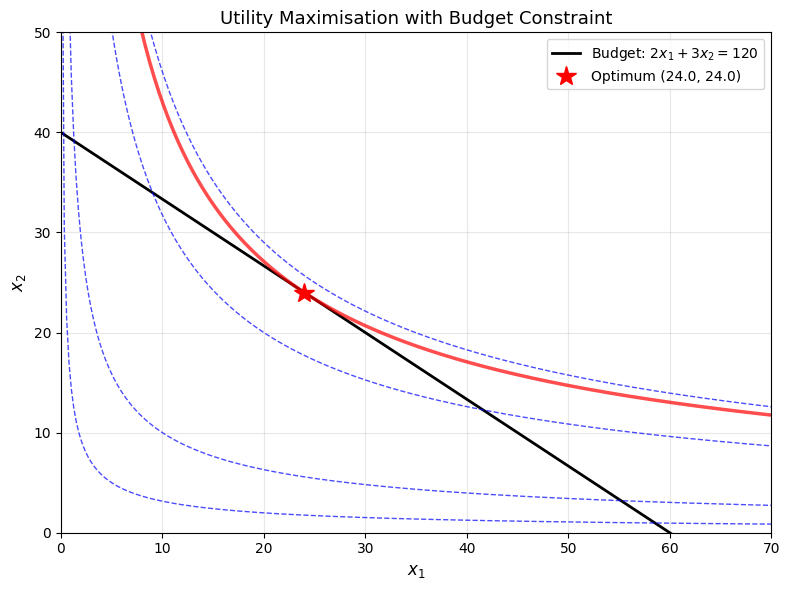

In [2]:
# Visualise: indifference curves and budget constraint
x1 = np.linspace(0.1, 70, 300)
x2_budget = (m - p1*x1) / p2

fig, ax = plt.subplots(figsize=(8, 6))

# Budget constraint
ax.plot(x1, x2_budget, 'k-', linewidth=2, label=f'Budget: ${p1}x_1 + {p2}x_2 = {m}$')

# Indifference curves
for u_level in [5, 10, u_star, 20, 25]:
    x2_ic = (u_level / x1**alpha)**(1/(1-alpha))
    style = 'r-' if abs(u_level - u_star) < 0.1 else 'b--'
    lw = 2.5 if abs(u_level - u_star) < 0.1 else 1
    ax.plot(x1, x2_ic, style, linewidth=lw, alpha=0.7)

ax.plot(x1_star, x2_star, 'r*', markersize=15, zorder=5,
        label=f'Optimum ({x1_star:.1f}, {x2_star:.1f})')
ax.set_xlim(0, 70); ax.set_ylim(0, 50)
ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Utility Maximisation with Budget Constraint', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The Envelope Theorem and Shadow Prices

The Lagrange multiplier $\lambda^*$ equals the marginal value of relaxing the constraint:

$$\frac{\partial V}{\partial m} = \lambda^*$$

where $V(m) = u(x_1^*(m), x_2^*(m))$ is the **indirect utility function**.

For our Cobb-Douglas example: $\lambda^* = \frac{\alpha^\alpha (1-\alpha)^{1-\alpha}}{p_1^\alpha p_2^{1-\alpha}} \cdot \frac{1}{1}$

In [3]:
# Verify the envelope theorem numerically
dm = 0.01
V_m = (alpha*m/p1)**alpha * ((1-alpha)*m/p2)**(1-alpha)
V_m_plus = (alpha*(m+dm)/p1)**alpha * ((1-alpha)*(m+dm)/p2)**(1-alpha)

numerical_lambda = (V_m_plus - V_m) / dm
analytical_lambda = alpha**alpha * (1-alpha)**(1-alpha) / (p1**alpha * p2**(1-alpha))

print(f"Numerical dV/dm  = {numerical_lambda:.6f}")
print(f"Analytical lambda = {analytical_lambda:.6f}")
print(f"\nInterpretation: An extra $1 of income raises utility by ~{analytical_lambda:.4f}")

Numerical dV/dm  = 0.200000
Analytical lambda = 0.200000

Interpretation: An extra $1 of income raises utility by ~0.2000


## 4. Multiple Constraints

For $k$ equality constraints $g_i(\mathbf{x}) = 0$, $i = 1, \ldots, k$:

$$\mathcal{L}(\mathbf{x}, \lambda_1, \ldots, \lambda_k) = f(\mathbf{x}) - \sum_{i=1}^k \lambda_i g_i(\mathbf{x})$$

**Constraint qualification:** The gradients $\nabla g_1, \ldots, \nabla g_k$ must be linearly independent at the optimum.

## Exercises

<details><summary><b>Exercise 1:</b> A firm minimises cost $C = w_1 x_1 + w_2 x_2$ subject to the production constraint $x_1^{0.5} x_2^{0.5} = \bar{y}$. Find the optimal input demands and the cost function $C(w_1, w_2, \bar{y})$.</summary>

Lagrangian: $\mathcal{L} = w_1 x_1 + w_2 x_2 + \lambda(\bar{y} - x_1^{0.5}x_2^{0.5})$

FOCs give $x_1^* = \bar{y}(w_2/w_1)^{0.5}$, $x_2^* = \bar{y}(w_1/w_2)^{0.5}$

Cost function: $C = 2\bar{y}(w_1 w_2)^{0.5}$
</details>

<details><summary><b>Exercise 2:</b> Verify the envelope theorem for the cost minimisation problem: $\partial C / \partial \bar{y} = \lambda^*$.</summary>

```python
w1, w2, ybar = 4, 9, 10
C = 2*ybar*(w1*w2)**0.5
# lambda = dC/dybar = 2*(w1*w2)**0.5 = 2*6 = 12
# Verify numerically...
```
</details>